In [2]:
# Notebooks specific imports
from IPython import get_ipython

ipython = get_ipython()
# Expand notebook display

# Display all cell outputs
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"
# autoreload extension
if "autoreload" not in ipython.extension_manager.loaded:
    %load_ext autoreload
%autoreload 2
from tqdm.notebook import tqdm

# Basic useful imports
import re
import time
import yaml
from pprint import pprint
from pathlib import Path
import h5py
from copy import deepcopy

# Data manipulation
import numpy as np
from scipy.special import erf
from scipy.integrate import quad, solve_ivp

from IPython.display import HTML
# Visualization
import matplotlib.animation as animation
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, RegularPolygon, FancyArrowPatch, ArrowStyle
from matplotlib.ticker import (
    MultipleLocator,
    FormatStrFormatter,
    AutoMinorLocator,
    NullFormatter,
)
import matplotlib.colors as colors
from cycler import cycler

from foxlink.graphs import ( me_graph_all_data_2d, draw_rod)

data_path = Path("../examples/new_me_test/NFIlMomentExpansionSolver.h5")
data_path.exists()


True

7.3591652315929394
-2.8208224698845324e-05


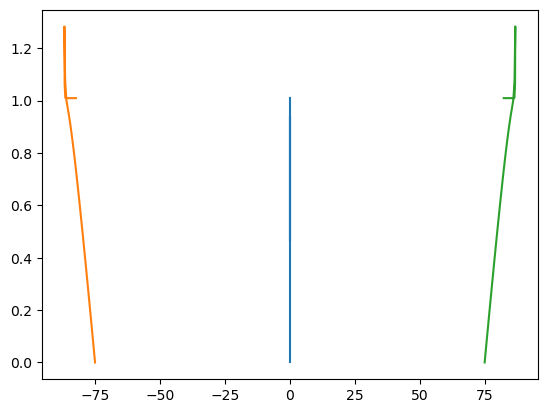

In [3]:
with h5py.File(data_path, 'r') as h5_data:
    rod_pos = h5_data['rod_data']['rod_pos'][...]
    plt.plot(rod_pos[0,0,:], rod_pos[0,1,:])
    plt.plot(rod_pos[1,0,:], rod_pos[1,1,:])
    plt.plot(rod_pos[2,0,:], rod_pos[2,1,:])
    print(rod_pos[1,0,0] - rod_pos[1,0,-1])
    print(rod_pos[0,0,0] - rod_pos[0,0,-1])
    # print(rod_pos[0,0,:])



(3, 4, 51)


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_99057/2541174788.py:12: SyntaxWarning: invalid escape sequence '\m'
  axarr[0].set_title('$\mu_{ij}^{00}$')
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_99057/2541174788.py:13: SyntaxWarning: invalid escape sequence '\m'
  axarr[1].set_title('$\mu_{ij}^{10}$')
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_99057/2541174788.py:14: SyntaxWarning: invalid escape sequence '\m'
  axarr[2].set_title('$\mu_{ij}^{01}$')
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_99057/2541174788.py:15: SyntaxWa

Text(0.5, 1.0, '$\\mu_{ij}^{00}$')

Text(0.5, 1.0, '$\\mu_{ij}^{10}$')

Text(0.5, 1.0, '$\\mu_{ij}^{01}$')

Text(0.5, 1.0, '$\\mu_{ij}^{11}$')

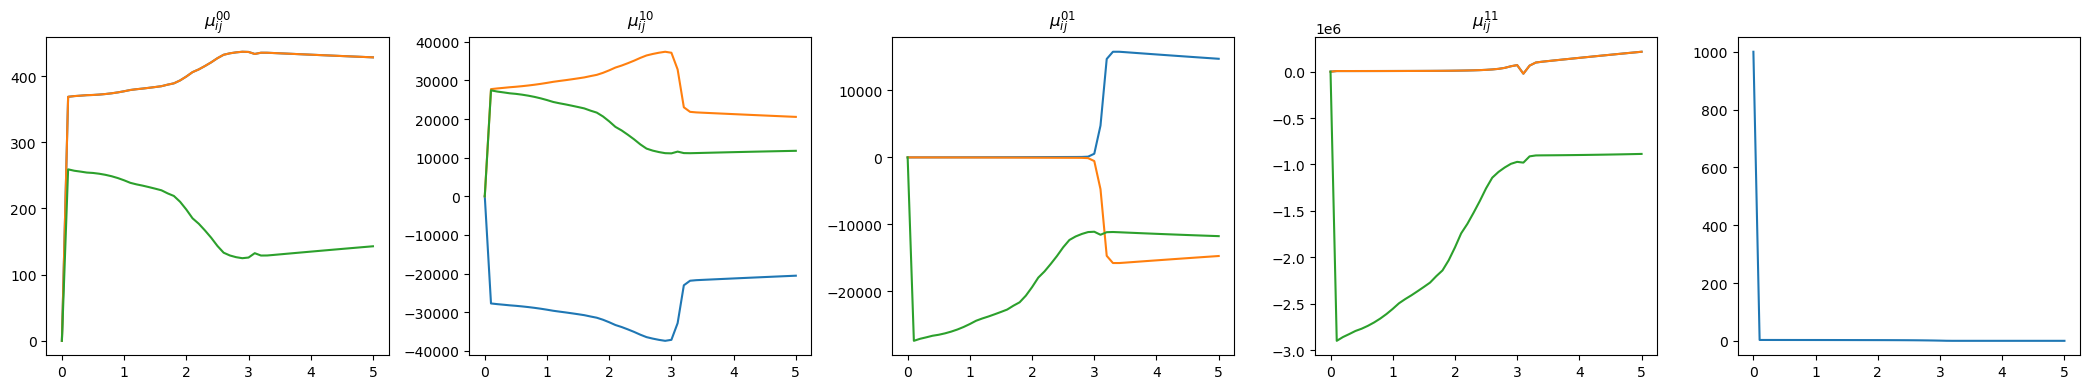

In [4]:
with h5py.File(data_path, 'r') as h5_data:
    fig, axarr = plt.subplots(1,5, figsize=(21, 4))
    
    print(h5_data['xl_data/moments'].shape)
    time_arr = h5_data['time'][...]
    for i in range(4):
        _ = axarr[i].plot(time_arr, h5_data['xl_data/moments'][0,i,:])
        _ = axarr[i].plot(time_arr, h5_data['xl_data/moments'][1,i,:])
        _ = axarr[i].plot(time_arr, h5_data['xl_data/moments'][2,i,:])
    _ = axarr[4].plot(time_arr, h5_data['xl_data/unbound'][:])

axarr[0].set_title('$\mu_{ij}^{00}$')
axarr[1].set_title('$\mu_{ij}^{10}$')
axarr[2].set_title('$\mu_{ij}^{01}$')
axarr[3].set_title('$\mu_{ij}^{11}$')
fig.tight_layout()


-0.2924213266453277
0.0


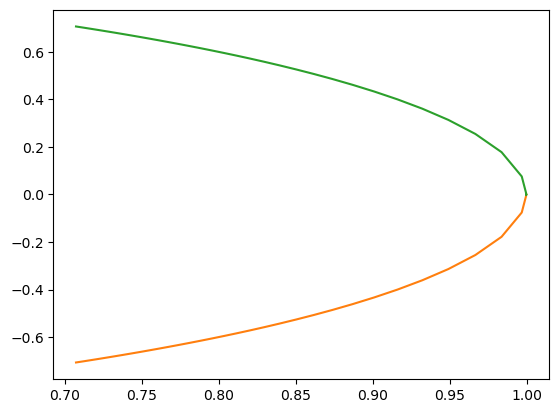

In [29]:
with h5py.File(data_path, 'r') as h5_data:
    rod_dirs = h5_data['rod_data']['rod_dirs'][...]
    plt.plot(rod_dirs[0,0,:], rod_dirs[0,1,:])
    plt.plot(rod_dirs[1,0,:], rod_dirs[1,1,:])
    plt.plot(rod_dirs[2,0,:], rod_dirs[2,1,:])
    print(rod_dirs[1,0,0] - rod_dirs[1,0,-1])
    print(rod_dirs[0,0,0] - rod_dirs[0,0,-1])
    # print(rod_pos[0,0,:])



(-250.0, 250.0)

(-250.0, 250.0)

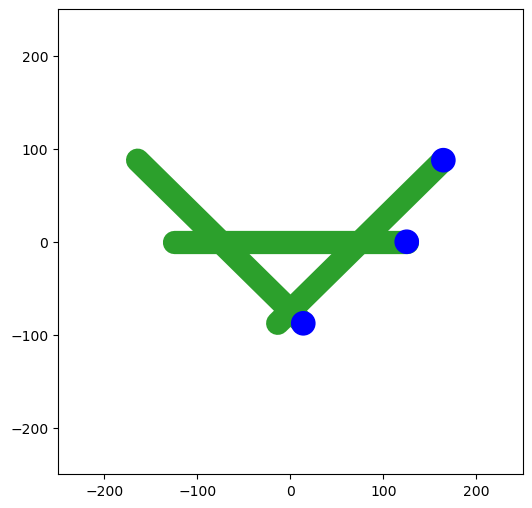

In [30]:
fig, axarr = plt.subplots(1,1, figsize=(6, 8))

with h5py.File(data_path, 'r') as h5_data:
    n=1
    rod_pos = h5_data['rod_data']['rod_pos'][...]
    rod_dirs = h5_data['rod_data']['rod_dirs'][...]
    rod_lengths = h5_data['rod_data']['rod_lengths'][:,n]
    # draw_rod(axarr, np.array([0,0,0]), np.array([1,0,0]), 1, .25)
    axarr.set_aspect('equal')
    draw_rod(axarr, rod_pos[0,[2,0,1],n], rod_dirs[0,[2,0,1],n], rod_lengths[0], 25)
    draw_rod(axarr, rod_pos[1,[2,0,1],n], rod_dirs[1,[2,0,1],n], rod_lengths[1], 25)
    draw_rod(axarr, rod_pos[2,[2,0,1],n], rod_dirs[2,[2,0,1],n], rod_lengths[2], 25)
    axarr.set_xlim(-250, 250)
    axarr.set_ylim(-250, 250)



In [39]:
fig, axarr = plt.subplots(1,1, figsize=(6, 8))
data_path = Path("../examples/new_me_test/NFIlMomentExpansionSolver.h5")
with h5py.File(data_path, 'r') as h5_data:
    rod_pos = h5_data['rod_data']['rod_pos'][...]
    rod_dirs = h5_data['rod_data']['rod_dirs'][...]
    rod_lengths = h5_data['rod_data']['rod_lengths'][...]

def draw_multi_rods(axarr, rod_pos, rod_dirs, rod_lengths,):
    for i in range(3):
        draw_rod(axarr, rod_pos[i,[2,0,1]], rod_dirs[i,[2,0,1]], rod_lengths[i], 25)
    axarr.set_xlim(-250, 250)
    axarr.set_ylim(-250, 250)

def init():
    axarr.set_aspect('equal')
    draw_multi_rods(axarr, rod_pos[:,:,0], rod_dirs[:,:,0], rod_lengths[:,0])
    axarr.set_xlim(-250, 250)
    axarr.set_ylim(-250, 250)
    return fig.gca().lines + fig.gca().collections

def animate(i):
    axarr.clear()
    for artist in fig.gca().lines + fig.gca().collections:
        artist.remove()
        del artist
    axarr.set_aspect('equal')
    draw_multi_rods(axarr, rod_pos[:,:,i], rod_dirs[:,:,i], rod_lengths[:,i])
    axarr.set_xlim(-250, 250)
    axarr.set_ylim(-250, 250)
    return fig.gca().lines + fig.gca().collections


ani = animation.FuncAnimation(fig, animate, init_func=init, frames=rod_pos.shape[-1], interval=60, blit=True)
ani.save('rods.mp4', writer='ffmpeg', fps=30)

HTML(ani.to_jshtml())
plt.close(fig)
# del axarr
# del fig

In [11]:
data_path = Path("../examples/new_me_test_no_cross/NFIlMomentExpansionSolver.h5")
fig, axarr = plt.subplots(1,1, figsize=(6, 8))
with h5py.File(data_path, 'r') as h5_data:
    rod_pos = h5_data['rod_data']['rod_pos'][...]
    rod_dirs = h5_data['rod_data']['rod_dirs'][...]
    rod_lengths = h5_data['rod_data']['rod_lengths'][...]

def draw_multi_rods(axarr, rod_pos, rod_dirs, rod_lengths,):
    for i in range(3):
        draw_rod(axarr, rod_pos[i,[2,0,1]], rod_dirs[i,[2,0,1]], rod_lengths[i], 25)
    axarr.set_xlim(-500, 500)
    axarr.set_ylim(-500, 500)

def init():
    axarr.set_aspect('equal')
    draw_multi_rods(axarr, rod_pos[:,:,0], rod_dirs[:,:,0], rod_lengths[:,0])
    axarr.set_xlim(-500, 500)
    axarr.set_ylim(-500, 500)
    return fig.gca().lines + fig.gca().collections

def animate(i):
    axarr.clear()
    for artist in fig.gca().lines + fig.gca().collections:
        artist.remove()
        del artist
    axarr.set_aspect('equal')
    draw_multi_rods(axarr, rod_pos[:,:,i], rod_dirs[:,:,i], rod_lengths[:,i])
    axarr.set_xlim(-500, 500)
    axarr.set_ylim(-500, 500)
    return fig.gca().lines + fig.gca().collections


ani = animation.FuncAnimation(fig, animate, init_func=init, frames=rod_pos.shape[-1], interval=60, blit=True)
ani.save('rods.mp4', writer='ffmpeg', fps=30)

HTML(ani.to_jshtml())
plt.close(fig)
# del axarr
# del fig

(3, 4, 51)


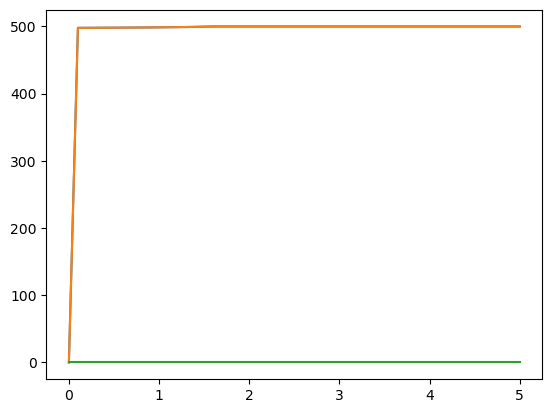

In [12]:
with h5py.File(data_path, 'r') as h5_data:
    print(h5_data['xl_data/moments'].shape)
    time_arr = h5_data['time'][...]
    plt.plot(time_arr, h5_data['xl_data/moments'][0,0,:])
    plt.plot(time_arr, h5_data['xl_data/moments'][1,0,:])
    plt.plot(time_arr, h5_data['xl_data/moments'][2,0,:])


In [33]:
data_path = Path("../examples/new_me_test_4fil/NFIlMomentExpansionSolver.h5")
fig, axarr = plt.subplots(1,1, figsize=(6, 8))
with h5py.File(data_path, 'r') as h5_data:
    rod_pos = h5_data['rod_data']['rod_pos'][...]
    rod_dirs = h5_data['rod_data']['rod_dirs'][...]
    rod_lengths = h5_data['rod_data']['rod_lengths'][...]

def draw_multi_rods(axarr, rod_pos, rod_dirs, rod_lengths,):
    for i in range(4):
        draw_rod(axarr, rod_pos[i,[2,0,1]], rod_dirs[i,[2,0,1]], rod_lengths[i], 25)
    axarr.set_xlim(-250, 250)
    axarr.set_ylim(-250, 250)

def init():
    axarr.set_aspect('equal')
    draw_multi_rods(axarr, rod_pos[:,:,0], rod_dirs[:,:,0], rod_lengths[:,0])
    axarr.set_xlim(-250, 250)
    axarr.set_ylim(-250, 250)
    return fig.gca().lines + fig.gca().collections

def animate(i):
    axarr.clear()
    for artist in fig.gca().lines + fig.gca().collections:
        artist.remove()
        del artist
    axarr.set_aspect('equal')
    draw_multi_rods(axarr, rod_pos[:,:,i], rod_dirs[:,:,i], rod_lengths[:,i])
    axarr.set_xlim(-500, 500)
    axarr.set_ylim(-500, 500)
    return fig.gca().lines + fig.gca().collections


ani = animation.FuncAnimation(fig, animate, init_func=init, frames=rod_pos.shape[-1], interval=60, blit=True)
ani.save('rods.mp4', writer='ffmpeg', fps=30)

HTML(ani.to_jshtml())
plt.close(fig)
# del axarr
# del fig

In [34]:
data_path = Path("../examples/new_me_test_4fil_staggered/NFIlMomentExpansionSolver.h5")
fig, axarr = plt.subplots(1,1, figsize=(6, 8))
with h5py.File(data_path, 'r') as h5_data:
    rod_pos = h5_data['rod_data']['rod_pos'][...]
    rod_dirs = h5_data['rod_data']['rod_dirs'][...]
    rod_lengths = h5_data['rod_data']['rod_lengths'][...]

def draw_multi_rods(axarr, rod_pos, rod_dirs, rod_lengths,):
    for i in range(4):
        draw_rod(axarr, rod_pos[i,[2,0,1]], rod_dirs[i,[2,0,1]], rod_lengths[i], 25)
    axarr.set_xlim(-250, 250)
    axarr.set_ylim(-250, 250)

def init():
    axarr.set_aspect('equal')
    draw_multi_rods(axarr, rod_pos[:,:,0], rod_dirs[:,:,0], rod_lengths[:,0])
    axarr.set_xlim(-250, 250)
    axarr.set_ylim(-250, 250)
    return fig.gca().lines + fig.gca().collections

def animate(i):
    axarr.clear()
    for artist in fig.gca().lines + fig.gca().collections:
        artist.remove()
        del artist
    axarr.set_aspect('equal')
    draw_multi_rods(axarr, rod_pos[:,:,i], rod_dirs[:,:,i], rod_lengths[:,i])
    axarr.set_xlim(-500, 500)
    axarr.set_ylim(-500, 500)
    return fig.gca().lines + fig.gca().collections


ani = animation.FuncAnimation(fig, animate, init_func=init, frames=rod_pos.shape[-1], interval=60, blit=True)
ani.save('rods.mp4', writer='ffmpeg', fps=30)

HTML(ani.to_jshtml())
plt.close(fig)
# del axarr
# del fig

In [23]:
sim_path = Path("../examples/nfil_10_rand_boxL500/")
# Generate random distribution of filaments in a region
n_fil = 10
length = 250
fil_arr = (2*np.random.rand(n_fil, 7) - 1) * length/2
# print(fil_arr)

for i, theta in enumerate(np.random.rand((n_fil))*2*np.pi):
    fil_arr[i, 3:] = [np.cos(theta), np.sin(theta), 0, length]

with (sim_path / 'new_me_test.yaml').open('r') as pf:
    params = yaml.safe_load(pf)
    params['rods'] = fil_arr.tolist()

with (sim_path / 'new_me_test.yaml').open('w') as pf:
    pf.write(yaml.dump(params))







1573

In [26]:
data_path = Path("../examples/nfil_10_rand_boxL500/NFIlMomentExpansionSolver.h5")
fig, axarr = plt.subplots(1,1, figsize=(6, 8))
with h5py.File(data_path, 'r') as h5_data:
    rod_pos = h5_data['rod_data']['rod_pos'][...]
    rod_dirs = h5_data['rod_data']['rod_dirs'][...]
    rod_lengths = h5_data['rod_data']['rod_lengths'][...]



ani = animation.FuncAnimation(fig, animate, init_func=init, frames=rod_pos.shape[-1], interval=60, blit=True)
ani.save('rods.mp4', writer='ffmpeg', fps=30)

HTML(ani.to_jshtml())
plt.close(fig)
# del axarr
# del fig

In [18]:
help(yaml.safe_load)

Help on function safe_load in module yaml:

safe_load(stream)
    Parse the first YAML document in a stream
    and produce the corresponding Python object.

    Resolve only basic YAML tags. This is known
    to be safe for untrusted input.



<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_72836/1211157758.py:11: SyntaxWarning: invalid escape sequence '\m'
  axarr.set_ylabel('$\mu_{ij}^{00}$')


True

(3, 4, 101)
(3, 4, 101)
(3, 4, 101)
(3, 4, 101)
(3, 4, 101)
(3, 4, 101)
(3, 4, 101)
(3, 4, 101)


Text(0, 0.5, '$\\mu_{ij}^{00}$')

Text(0.5, 0, 'time $t$ [$s$]')

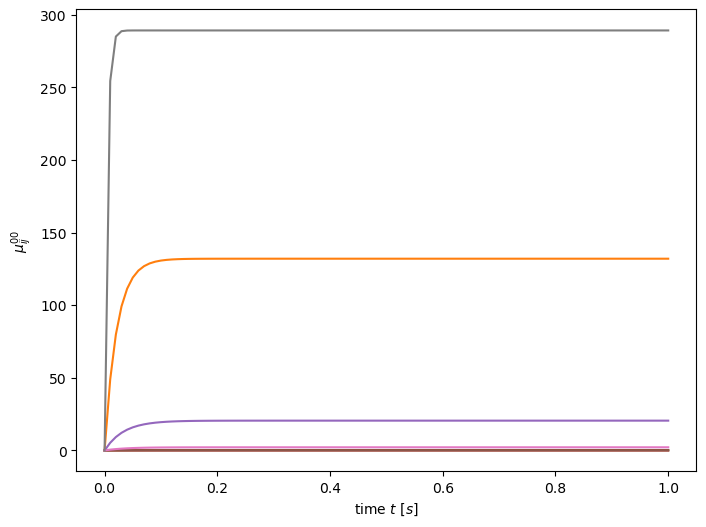

In [29]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/overlap_3_rods_ke_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,1, figsize=(8, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        print(h5_data['xl_data/moments'].shape)
        time_arr = h5_data['time'][...]
        _ = axarr.plot(time_arr, h5_data['xl_data/moments'][0,0,:])

axarr.set_ylabel('$\mu_{ij}^{00}$')
axarr.set_xlabel('time $t$ [$s$]')  


True

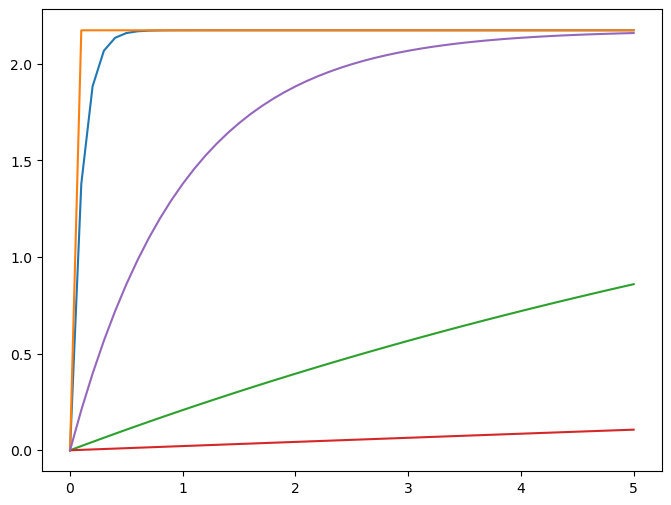

In [24]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/overlap_3_rods_ko_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,1, figsize=(8, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        time_arr = h5_data['time'][...]
        _ = axarr.plot(time_arr, h5_data['xl_data/moments'][0,0,:])

True

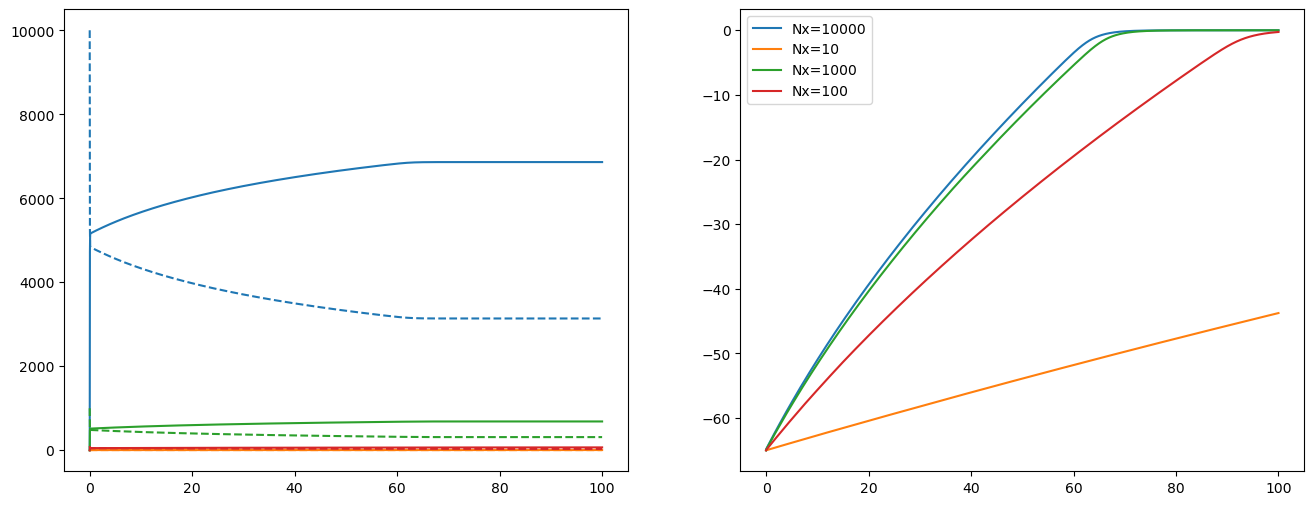

In [13]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_2_rods_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'Nx={params["n_unbound"]}')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[1].plot(time_arr, h5_data['rod_data/rod_pos'][0,0,:], label=f'Nx={params["n_unbound"]}')
axarr[1].legend()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_99057/851089658.py:14: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].set_ylabel('$\mu_{ij}^{00}$')


True

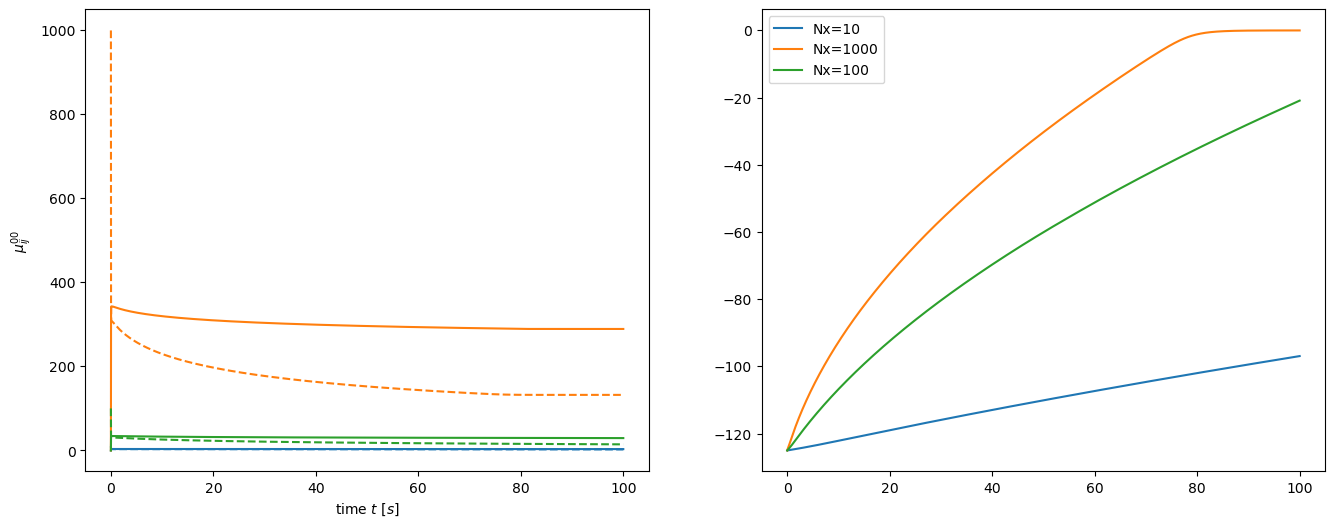

In [16]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_3_rods_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'Nx={params["n_unbound"]}')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[1].plot(time_arr, h5_data['rod_data/rod_pos'][0,0,:], label=f'Nx={params["n_unbound"]}')
_ = axarr[1].legend()
_ = axarr[0].set_ylabel('$\mu_{ij}^{00}$')
_ = axarr[0].set_xlabel('time $t$ [$s$]')
# _ = axarr[0].set_yscale('log')

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_99057/3773918829.py:22: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].set_ylabel('$\mu_{ij}^{00}$')


True

(3, 4, 10001)


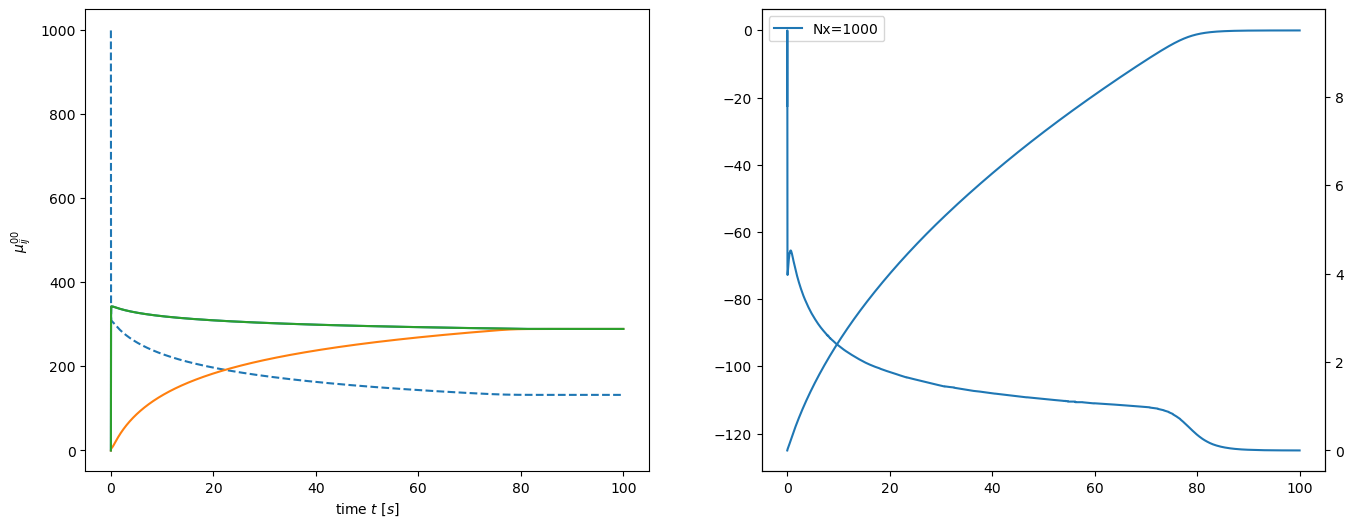

In [23]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_3_rods_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in list(data_path.glob('**/*.h5'))[1:]:
    with h5py.File(h5_data, 'r') as h5_data:
        print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'pair 1')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][1,0,:], label=f'pair 2')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][2,0,:], label=f'pair 3')
        rod_pos = h5_data['rod_data']['rod_pos'][0,0,:] 
        rod_vel = np.diff(rod_pos)/np.diff(time_arr)[-1]
        _ = axarr[1].plot(time_arr, rod_pos, label=f'Nx={params["n_unbound"]}')
        axshare = axarr[1].twinx()
        _ = axshare.plot(time_arr[:-1], rod_vel, label=f'Nx={params["n_unbound"]}')

    break
_ = axarr[1].legend()
_ = axarr[0].set_ylabel('$\mu_{ij}^{00}$')
_ = axarr[0].set_xlabel('time $t$ [$s$]')
# _ = axarr[0].set_yscale('log')

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_99057/20596242.py:20: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].set_ylabel('$\mu_{ij}^{00}$')


True

(1, 4, 10001)


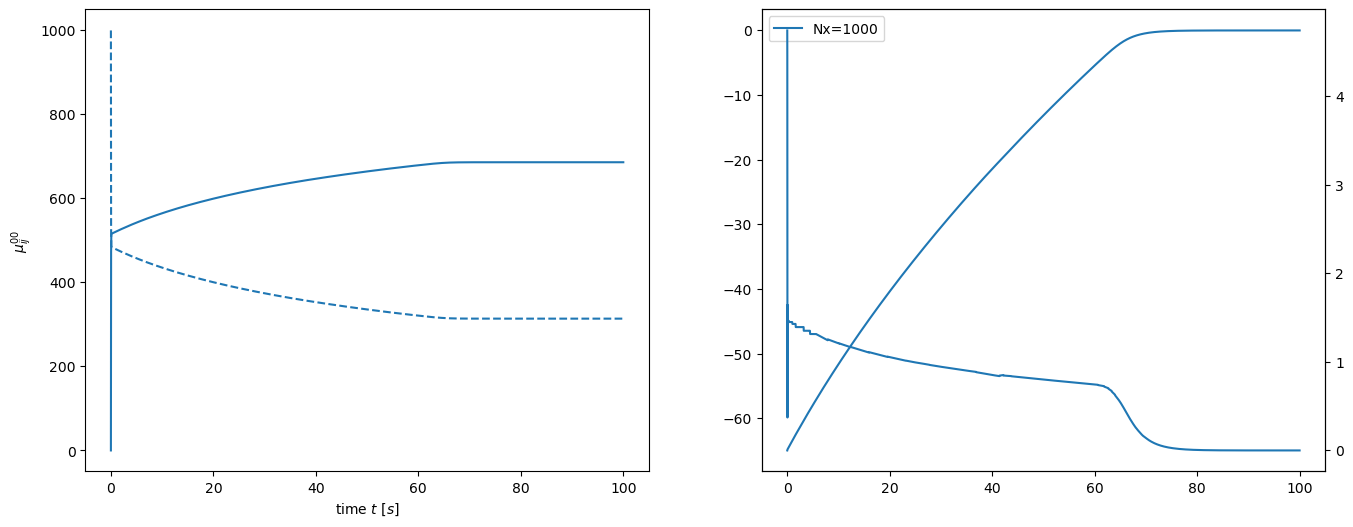

In [27]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_2_rods_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in list(data_path.glob('**/*.h5'))[2:]:
    with h5py.File(h5_data, 'r') as h5_data:
        print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'pair 1')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        rod_pos = h5_data['rod_data']['rod_pos'][0,0,:] 
        rod_vel = np.diff(rod_pos)/np.diff(time_arr)[-1]
        _ = axarr[1].plot(time_arr, rod_pos, label=f'Nx={params["n_unbound"]}')
        axshare = axarr[1].twinx()
        _ = axshare.plot(time_arr[:-1], rod_vel, label=f'Nx={params["n_unbound"]}')

    break
_ = axarr[1].legend()
_ = axarr[0].set_ylabel('$\mu_{ij}^{00}$')
_ = axarr[0].set_xlabel('time $t$ [$s$]')
# _ = axarr[0].set_yscale('log')

True

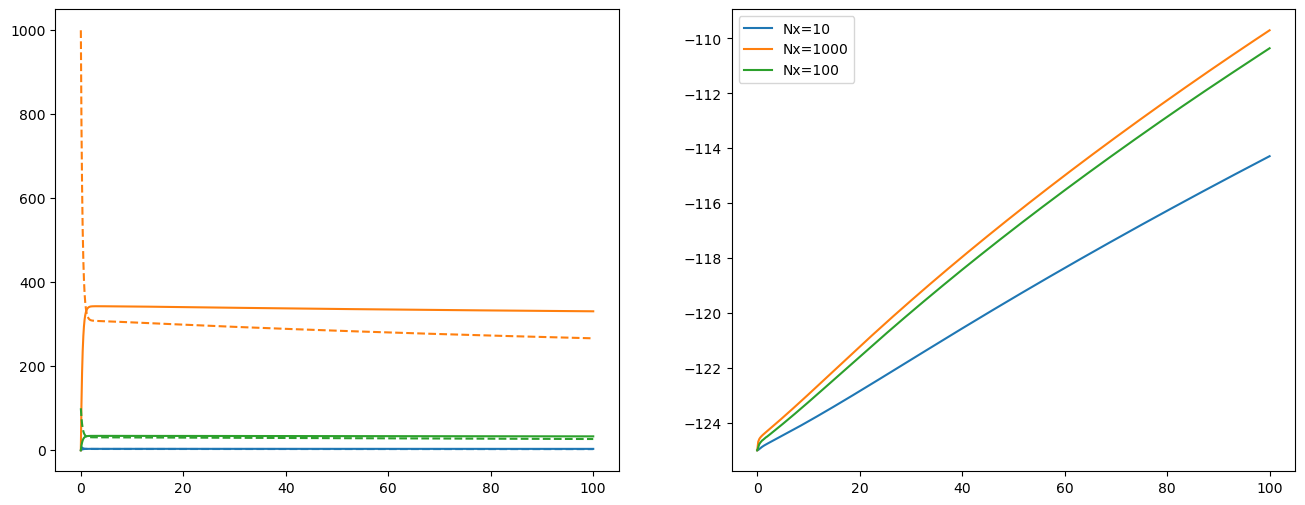

In [28]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_3_rods_Nx_scan_ko1/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'Nx={params["n_unbound"]}')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[1].plot(time_arr, h5_data['rod_data/rod_pos'][0,0,:], label=f'Nx={params["n_unbound"]}')
axarr[1].legend()

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_99057/797991756.py:22: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].set_ylabel('$\mu_{ij}^{00}$')


True

(3, 4, 10001)


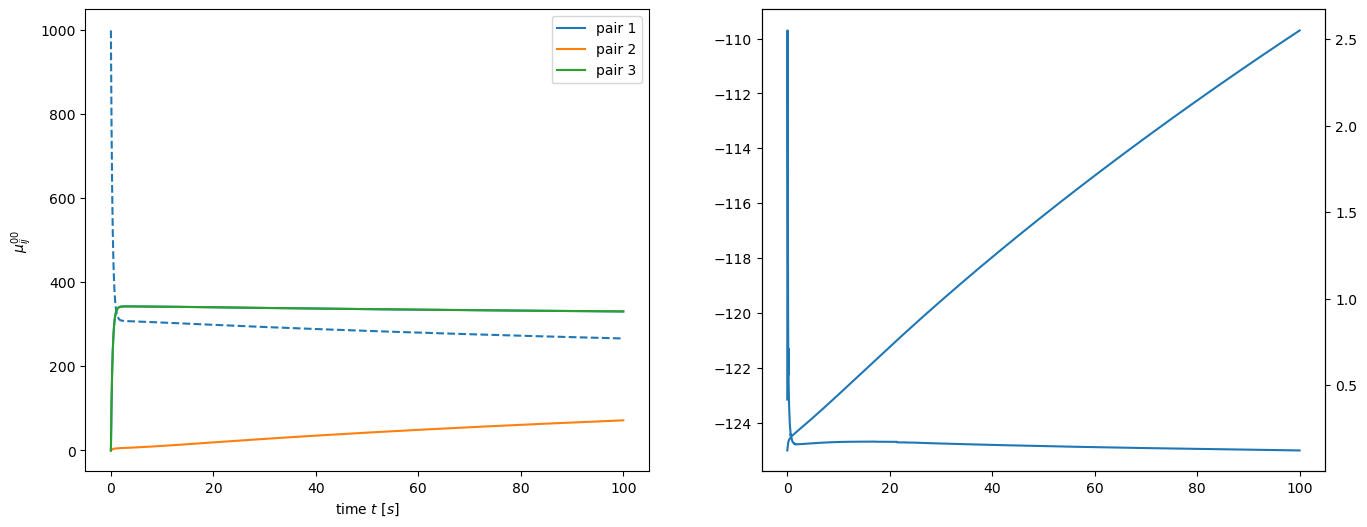

In [30]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_3_rods_Nx_scan_ko1/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in list(data_path.glob('**/*.h5'))[1:]:
    with h5py.File(h5_data, 'r') as h5_data:
        print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'pair 1')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][1,0,:], label=f'pair 2')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][2,0,:], label=f'pair 3')
        rod_pos = h5_data['rod_data']['rod_pos'][0,0,:] 
        rod_vel = np.diff(rod_pos)/np.diff(time_arr)[-1]
        _ = axarr[1].plot(time_arr, rod_pos, label=f'Nx={params["n_unbound"]}')
        axshare = axarr[1].twinx()
        _ = axshare.plot(time_arr[:-1], rod_vel, label=f'Nx={params["n_unbound"]}')

    break
_ = axarr[0].legend()
_ = axarr[0].set_ylabel('$\mu_{ij}^{00}$')
_ = axarr[0].set_xlabel('time $t$ [$s$]')
# _ = axarr[0].set_yscale('log')